# Análise de Entidades Extraídas com GLiNER

Este notebook realiza uma análise exploratória dos dados processados, enténdendo a distribuição de entidades, tendências de sentimento e insights sobre feedback dos consumidores.

## Etapas:

1. **Carregamento dos Dados**: Importa o arquivo com entidades extraídas.
2. **Exploração de Dados**: Estatísticas sobre distribuição de labels e frequências.
3. **Visualizações**: Gráficos para melhor compreensão dos padrões.
4. **Insights de Sentimento**: Análise de elogios vs. críticas.
5. **Produtos mais Mencionados**: Ranking de produtos por frequência.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

# configurar estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Carregar o arquivo processado
# NOTA: ajuste o caminho conforme o arquivo que você quer analisar
arquivo = '../data/processed/reviews_10pct_duckdb_com_entidades.csv'
df = pd.read_csv(arquivo)

print(f"Arquivo carregado: {arquivo}")
print(f"Total de linhas: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
print(df.head())

Arquivo carregado: ../data/processed/reviews_10pct_duckdb_com_entidades.csv
Total de linhas: 20695
Colunas: ['date', 'rating', 'content', 'product_url', 'analise_ia']

Primeiras linhas:
           date  rating                                            content  \
0  19 jan. 2025       5  Uso muito no verão e atende bem a minha expect...   
1  24 dez. 2023       5                           Produto excelente, amei.   
2  22 nov. 2024       5                            Maravilhosa as ampolas.   
3  23 mai. 2024       5                               Perfeito. P pentear.   
4  02 dez. 2020       5                Muito bom um pouco caro.\nObrigado.   

                                         product_url  \
0  https://www.mercadolivre.com.br/loco-camomila-...   
1  https://www.mercadolivre.com.br/absolut-repair...   
2  https://www.mercadolivre.com.br/cronograma-cap...   
3  https://www.mercadolivre.com.br/elseve-creme-p...   
4  https://produto.mercadolivre.com.br/MLB-142528...   

        

In [17]:
# Explorar a coluna 'analise_ia' que contém as entidades
# As entidades estão em formato string (representação de lista)
print("Exemplo de entidades extraídas:")
for idx in range(min(3, len(df))):
    print(f"\nReview {idx}:")
    print(f"Conteúdo: {df['content'].iloc[idx][:100]}...")
    print(f"Entidades: {df['analise_ia'].iloc[idx]}")

Exemplo de entidades extraídas:

Review 0:
Conteúdo: Uso muito no verão e atende bem a minha expectativa , sem precisar de tintura....
Entidades: []

Review 1:
Conteúdo: Produto excelente, amei....
Entidades: [{'start': 0, 'end': 7, 'text': 'Produto', 'label': 'produto', 'score': 0.6294851303100586}, {'start': 19, 'end': 23, 'text': 'amei', 'label': 'produto', 'score': 0.40183719992637634}]

Review 2:
Conteúdo: Maravilhosa as ampolas....
Entidades: []


In [18]:
# Converter entidades de string para lista (se necessário)
# Avaliar se as células contêm strings ou listas
def parse_entities(entity_string):
    """Converte representação em string para lista de dicts"""
    try:
        if isinstance(entity_string, str):
            return json.loads(entity_string.replace("'", '"'))
        return entity_string
    except:
        return []

# Aplicar parse (comentado - descomentar se necessário)
# df['entities_list'] = df['analise_ia'].apply(parse_entities)

print("Tipo de dados em 'analise_ia':")
print(type(df['analise_ia'].iloc[0]))
print(f"\nAmostra: {df['analise_ia'].iloc[0]}")

Tipo de dados em 'analise_ia':
<class 'str'>

Amostra: []


In [19]:
# Contar entidades por tipo (label)
# Estatísticas sobre a extração

label_counts = Counter()
entity_texts = {}

for idx, row in df.iterrows():
    entities = parse_entities(row['analise_ia'])
    for ent in entities:
        label = ent.get('label', 'unknown')
        text = ent.get('text', '')
        label_counts[label] += 1
        
        if label not in entity_texts:
            entity_texts[label] = Counter()
        entity_texts[label][text] += 1

print("Distribuição de Entidades por Tipo:")
print("="*40)
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label:25s}: {count:6d} ocorrências")

print(f"\nTotal de entidades extraídas: {sum(label_counts.values())}")

Distribuição de Entidades por Tipo:
produto                  :   9167 ocorrências
elogio                   :   2350 ocorrências
caracteristica_item      :   1794 ocorrências
beneficio_prometido      :    359 ocorrências
critica                  :    331 ocorrências

Total de entidades extraídas: 14001


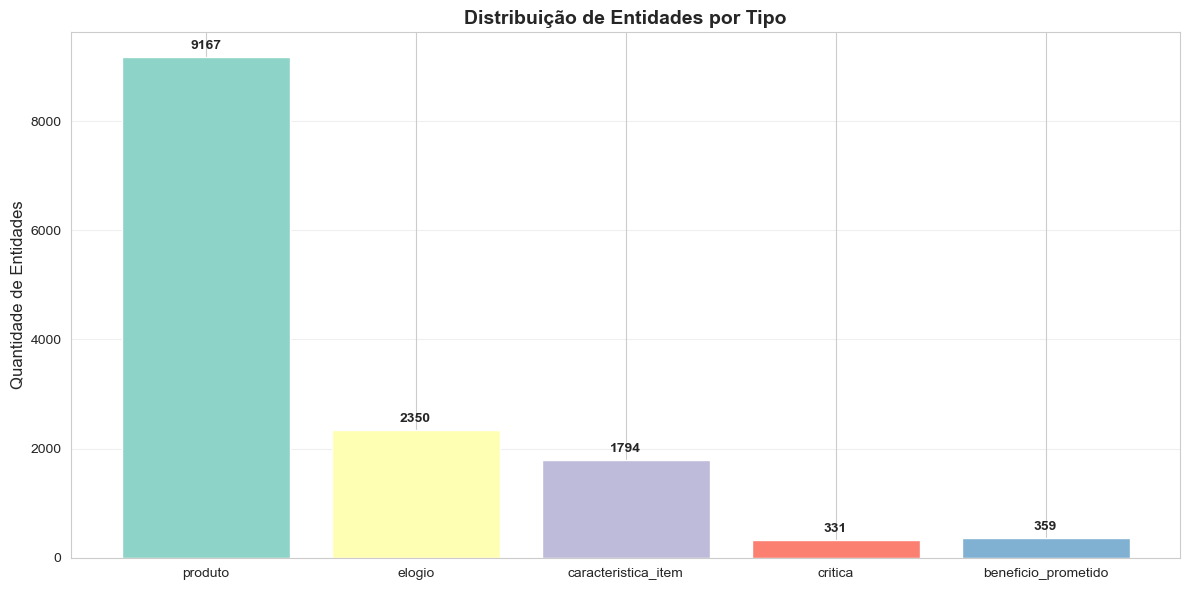

In [20]:
# Visualizar distribuição de labels
fig, ax = plt.subplots()
labels = list(label_counts.keys())
counts = list(label_counts.values())

colors = plt.cm.Set3(range(len(labels)))
ax.bar(labels, counts, color=colors)
ax.set_ylabel('Quantidade de Entidades', fontsize=12)
ax.set_title('Distribuição de Entidades por Tipo', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/distribuicao_entidades.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Top 10 entidades mais frequentes por tipo
print("\nEntidades Mais Frequentes por Tipo:")
print("="*60)

for label in sorted(entity_texts.keys()):
    print(f"\n{label.upper()}:")
    top_entities = entity_texts[label].most_common(10)
    for entity, count in top_entities:
        print(f"  {entity:35s} | {count:4d}x")


Entidades Mais Frequentes por Tipo:

BENEFICIO_PROMETIDO:
  Gostei                              |   66x
  custo benefício                     |   29x
  Amei                                |   24x
  beneficio                           |   17x
  Excelente                           |   12x
  benefício                           |   12x
  Obrigada                            |    8x
  benefícios                          |    8x
  Bom                                 |    7x
  Amo                                 |    7x

CARACTERISTICA_ITEM:
  maravilhoso                         |   51x
  cheiroso                            |   42x
  qualidade                           |   38x
  Ótima qualidade                     |   32x
  macio                               |   31x
  Maravilhoso                         |   28x
  durabilidade                        |   28x
  consistência                        |   25x
  frizz                               |   23x
  Muito bom                           |   23x


Análise de Sentimento:
Elogios:    2350 (87.7%)
Críticas:    331 (12.3%)
Total:      2681


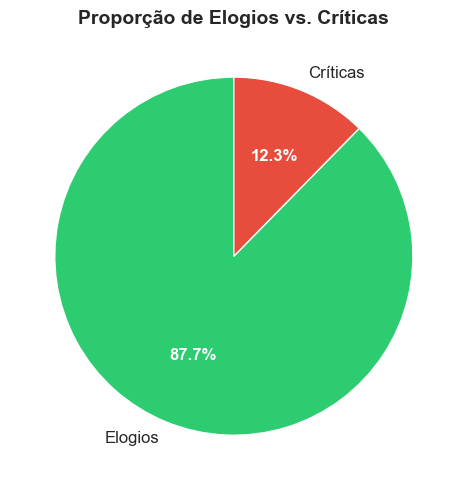

In [ ]:
# Análise de Sentimento: Elogios vs. Críticas
elogios = entity_texts.get('elogio', Counter())
criticas = entity_texts.get('critica', Counter())

total_elogios = sum(elogios.values())
total_criticas = sum(criticas.values())
total_sentimentos = total_elogios + total_criticas

if total_sentimentos > 0:
    pct_elogios = (total_elogios / total_sentimentos) * 100
    pct_criticas = (total_criticas / total_sentimentos) * 100
else:
    pct_elogios = pct_criticas = 0

print("\nAnálise de Sentimento:")
print("="*40)
print(f"Elogios:  {total_elogios:6d} ({pct_elogios:.1f}%)")
print(f"Críticas: {total_criticas:6d} ({pct_criticas:.1f}%)")
print(f"Total:    {total_sentimentos:6d}")

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
sentimentos = ['Elogios', 'Críticas']
valores = [total_elogios, total_criticas]
cores = ['#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax.pie(valores, labels=sentimentos, autopct='%1.1f%%',
                                    colors=cores, startangle=90, textprops={'fontsize': 12})
ax.set_title('Proporção de Elogios vs. Críticas', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('../images/sentimento_pie.png', dpi=300, bbox_inches='tight')
plt.show()


Top 15 Produtos Mais Mencionados:
 1. Produto                             | 1401x
 2. produto                             |  893x
 3. O produto                           |  416x
 4. Bom                                 |  332x
 5. o produto                           |  288x
 6. Amei                                |  265x
 7. Maravilhoso                         |  249x
 8. Ótimo produto                       |  233x
 9. shampoo                             |  219x
10. Excelente produto                   |  168x
11. esse produto                        |  165x
12. Esse produto                        |   94x
13. máscara                             |   86x
14. kit                                 |   67x
15. Shampoo                             |   62x


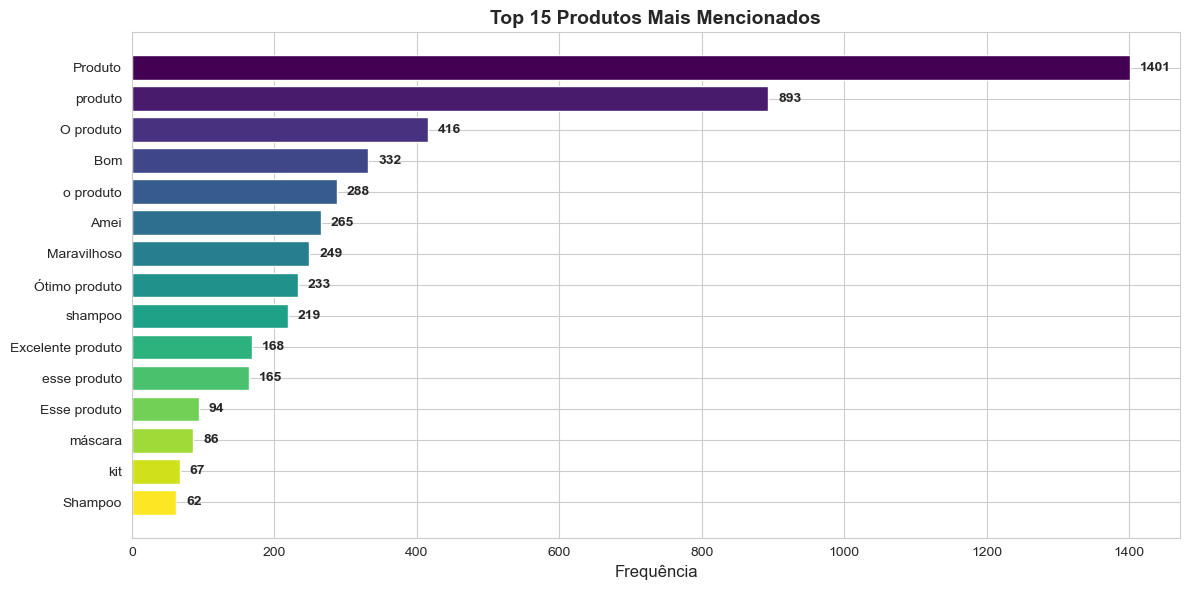

In [23]:
# Produtos mais mencionados
produtos = entity_texts.get('produto', Counter())

if produtos:
    top_produtos = produtos.most_common(15)
    
    print("\nTop 15 Produtos Mais Mencionados:")
    print("="*50)
    for i, (produto, count) in enumerate(top_produtos, 1):
        print(f"{i:2d}. {produto:35s} | {count:4d}x")
    
    # Visualização
    fig, ax = plt.subplots(figsize=(12, 6))
    produtos_names = [p[0][:30] for p in top_produtos]  # truncar nomes longos
    produtos_counts = [p[1] for p in top_produtos]
    
    ax.barh(produtos_names, produtos_counts, color=plt.cm.viridis(np.linspace(0, 1, len(top_produtos))))
    ax.set_xlabel('Frequência', fontsize=12)
    ax.set_title('Top 15 Produtos Mais Mencionados', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # Adicionar valores nas barras
    for i, v in enumerate(produtos_counts):
        ax.text(v + max(produtos_counts)*0.01, i, str(v), va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../images/top_produtos.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNenhum produto foi extraído nesta análise.")


Top 12 Benefícios Mais Prometidos:
 1. Gostei                              |   66x
 2. custo benefício                     |   29x
 3. Amei                                |   24x
 4. beneficio                           |   17x
 5. Excelente                           |   12x
 6. benefício                           |   12x
 7. Obrigada                            |    8x
 8. benefícios                          |    8x
 9. Bom                                 |    7x
10. Amo                                 |    7x
11. Maravilhoso                         |    6x
12. amei                                |    6x


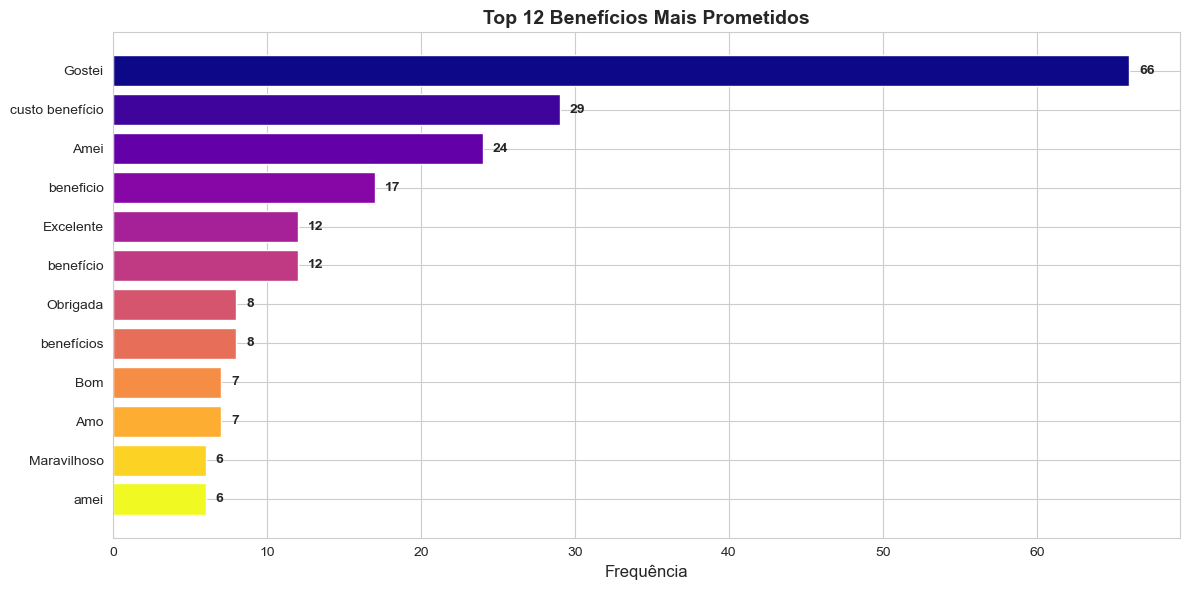

In [24]:
# Benefícios mais prometidos
beneficios = entity_texts.get('beneficio_prometido', Counter())

if beneficios:
    top_beneficios = beneficios.most_common(12)
    
    print("\nTop 12 Benefícios Mais Prometidos:")
    print("="*50)
    for i, (beneficio, count) in enumerate(top_beneficios, 1):
        print(f"{i:2d}. {beneficio:35s} | {count:4d}x")
    
    # Visualização
    fig, ax = plt.subplots(figsize=(12, 6))
    beneficios_names = [b[0][:30] for b in top_beneficios]
    beneficios_counts = [b[1] for b in top_beneficios]
    
    ax.barh(beneficios_names, beneficios_counts, color=plt.cm.plasma(np.linspace(0, 1, len(top_beneficios))))
    ax.set_xlabel('Frequência', fontsize=12)
    ax.set_title('Top 12 Benefícios Mais Prometidos', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, v in enumerate(beneficios_counts):
        ax.text(v + max(beneficios_counts)*0.01, i, str(v), va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../images/top_beneficios.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\nNenhum benefício foi extraído nesta análise.")

In [25]:
# Resumo final com insights
print("\n" + "="*60)
print("RESUMO E INSIGHTS")
print("="*60)

print(f"\n✓ Total de reviews analisados: {len(df)}")
print(f"✓ Total de entidades extraídas: {sum(label_counts.values())}")
print(f"✓ Média de entidades por review: {sum(label_counts.values()) / len(df):.2f}")

if pct_elogios > pct_criticas:
    print(f"\n✓ Sentimento geral: POSITIVO ({pct_elogios:.1f}% elogios)")
else:
    print(f"\n✓ Sentimento geral: CRÍTICO ({pct_criticas:.1f}% críticas)")

if produtos:
    top_produto = produtos.most_common(1)[0]
    print(f"✓ Produto mais mencionado: {top_produto[0]} ({top_produto[1]}x)")

if beneficios:
    top_beneficio = beneficios.most_common(1)[0]
    print(f"✓ Benefício mais prometido: {top_beneficio[0]} ({top_beneficio[1]}x)")

print(f"\n" + "="*60)


RESUMO E INSIGHTS

✓ Total de reviews analisados: 20695
✓ Total de entidades extraídas: 14001
✓ Média de entidades por review: 0.68

✓ Sentimento geral: POSITIVO (87.7% elogios)
✓ Produto mais mencionado: Produto (1401x)
✓ Benefício mais prometido: Gostei (66x)

